#  Student CGPA Prediction — Linear Regression

**Dataset:** `student_dropout_dataset_v3.csv`  
**Task:** Regression — Prediksi nilai **CGPA** mahasiswa  
**Model:** Linear Regression

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../student_dropout_dataset_v3.csv')
print('Shape:', df.shape)
df.info()

Shape: (10000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-nul

Statistik CGPA (target):
count    10000.000000
mean         2.298761
std          1.072555
min          0.000000
25%          1.520000
50%          2.350000
75%          3.150000
max          4.000000
Name: CGPA, dtype: float64


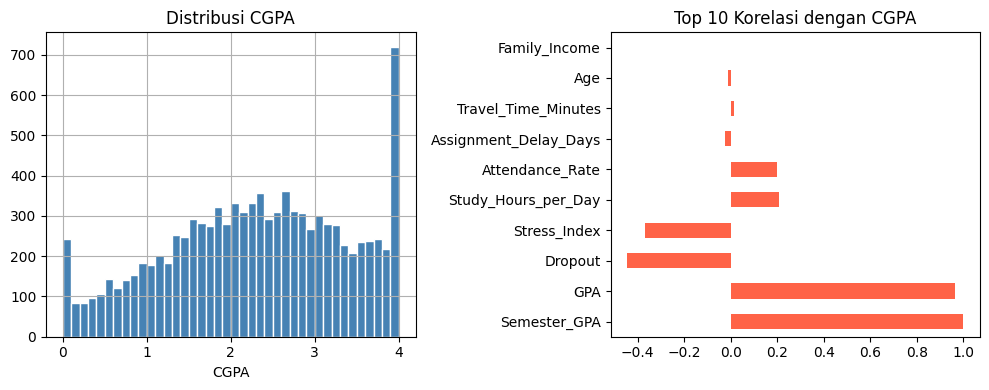

In [3]:
print('Statistik CGPA (target):')
print(df['CGPA'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['CGPA'].hist(bins=40, color='steelblue', edgecolor='white')
plt.title('Distribusi CGPA')
plt.xlabel('CGPA')

plt.subplot(1, 2, 2)
# Korelasi fitur numerik dengan CGPA
num_cols = df.select_dtypes(include='number').drop(columns=['Student_ID']).columns
corr = df[num_cols].corr()['CGPA'].drop('CGPA').sort_values(key=abs, ascending=False)
corr.head(10).plot(kind='barh', color='tomato')
plt.title('Top 10 Korelasi dengan CGPA')
plt.tight_layout()
plt.show()

---
## 2.  Dataset Bisa Digunakan Untuk Apa

| Tujuan | Target | Jenis |
|--------|--------|-------|
| Prediksi Dropout | `Dropout` | Classification |
| **Prediksi CGPA** ← (ini) | `CGPA` | **Regression** |
| Prediksi Semester GPA | `Semester_GPA` | Regression |
| Analisis faktor akademik | - | EDA |

---
## 3.  Model Yang Bisa Digunakan Untuk Regression

| Model | Keunggulan | Batas |
|-------|------------|-------|
| **Linear Regression** ← | Sederhana, cepat, interpretable | Hanya linear |
| Ridge/Lasso/ElasticNet | Regularisasi, handle multicollinearity | Masih linear |
| Random Forest Regressor | Non-linear, robust | Kurang smooth |
| XGBoost Regressor | Sangat akurat tabular data | Banyak hyperparameter |
| SVR | Efektif data kecil | Lambat data besar |

**Varian Linear Regression:**
- `LinearRegression` → Polos, tidak ada regularisasi
- `Ridge` (L2) → Shrink semua koefisien, handle multicollinearity
- `Lasso` (L1) → Bisa zero-out koefisien (feature selection)
- `ElasticNet` (L1+L2) → Kombinasi Ridge dan Lasso

In [4]:
# Preprocessing
target_col = 'CGPA'
drop_cols = ['Student_ID', 'Dropout', 'GPA', 'Semester_GPA']  # Hapus target lain dan kolom sangat correlated

df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target_col])
y = df_proc[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Imputasi nilai null dengan median
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

# Scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_imp)
X_test_s  = scaler.transform(X_test_imp)

print(f'Fitur: {X.shape[1]}, Train: {len(X_train)}, Test: {len(X_test)}')

Fitur: 14, Train: 8000, Test: 2000


---
## 4.  Parameter Yang Bisa Diubah / Disetel

### LinearRegression:
| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `fit_intercept` | True | Apakah hitung bias/intercept |
| `positive` | False | Paksa koefisien positif |

### Ridge:
| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `alpha` | 1.0 | Regularisasi strength. Semakin besar, semakin shrink koefisien |

### Lasso:
| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `alpha` | 1.0 | Regularisasi L1. Lebih besar bisa zero-out fitur |

### ElasticNet:
| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `alpha` | 1.0 | Total regularisasi |
| `l1_ratio` | 0.5 | 0=Ridge, 1=Lasso, 0.5=campuran |

**LinearRegression tidak memiliki hyperparameter tuning yang berarti.** Jika performa kurang baik, pertimbangkan Ridge/Lasso.

In [5]:
# Bandingkan beberapa varian Linear Regression
models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10)': Ridge(alpha=10.0),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []
for name, m in models.items():
    m.fit(X_train_s, y_train)
    y_pred = m.predict(X_test_s)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)})

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print(results_df.to_string(index=False))

             Model    MAE   RMSE     R²
Lasso (alpha=0.01) 0.8239 0.9981 0.1490
 Linear Regression 0.8235 0.9984 0.1485
 Ridge (alpha=0.1) 0.8235 0.9984 0.1485
 Ridge (alpha=1.0) 0.8235 0.9984 0.1485
  Ridge (alpha=10) 0.8235 0.9984 0.1485
        ElasticNet 0.8278 0.9995 0.1465


In [6]:
# Train model utama: Linear Regression
model = LinearRegression()
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)
print('Model Linear Regression berhasil ditraining ')

Model Linear Regression berhasil ditraining 


---
## 5.  Evaluasi Yang Dipakai

### Metrik Regression:

| Metrik | Formula | Penjelasan | Terbaik |
|--------|---------|------------|---------|
| **MAE** (Mean Absolute Error) | MAE = mean(|y - ŷ|) | Rata-rata error absolut. Mudah diinterpretasi | Mendekati 0 |
| **MSE** (Mean Squared Error) | MSE = mean((y - ŷ)²) | Error dikuadratkan, lebih sensitif outlier | Mendekati 0 |
| **RMSE** (Root MSE) | √MSE | Satuan sama dengan target, lebih interpretable dari MSE | Mendekati 0 |
| **R²** (R-squared) | 1 - SS_res/SS_tot | Proporsi varians yang dijelaskan model (0 – 1) | Mendekati 1 |

**Contoh Interpretasi MAE:**  
Jika MAE = 0.15, artinya rata-rata prediksi meleset ±0.15 poin CGPA dari nilai sebenarnya.

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=' * 50)
print(' EVALUASI MODEL LINEAR REGRESSION (CGPA)')
print('=' * 50)
print(f'MAE  : {mae:.4f}  (avg kesalahan ±{mae:.2f} poin CGPA)')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}  (model menjelaskan {r2*100:.1f}% varians CGPA)')

 EVALUASI MODEL LINEAR REGRESSION (CGPA)
MAE  : 0.8235  (avg kesalahan ±0.82 poin CGPA)
MSE  : 0.9968
RMSE : 0.9984
R²   : 0.1485  (model menjelaskan 14.8% varians CGPA)


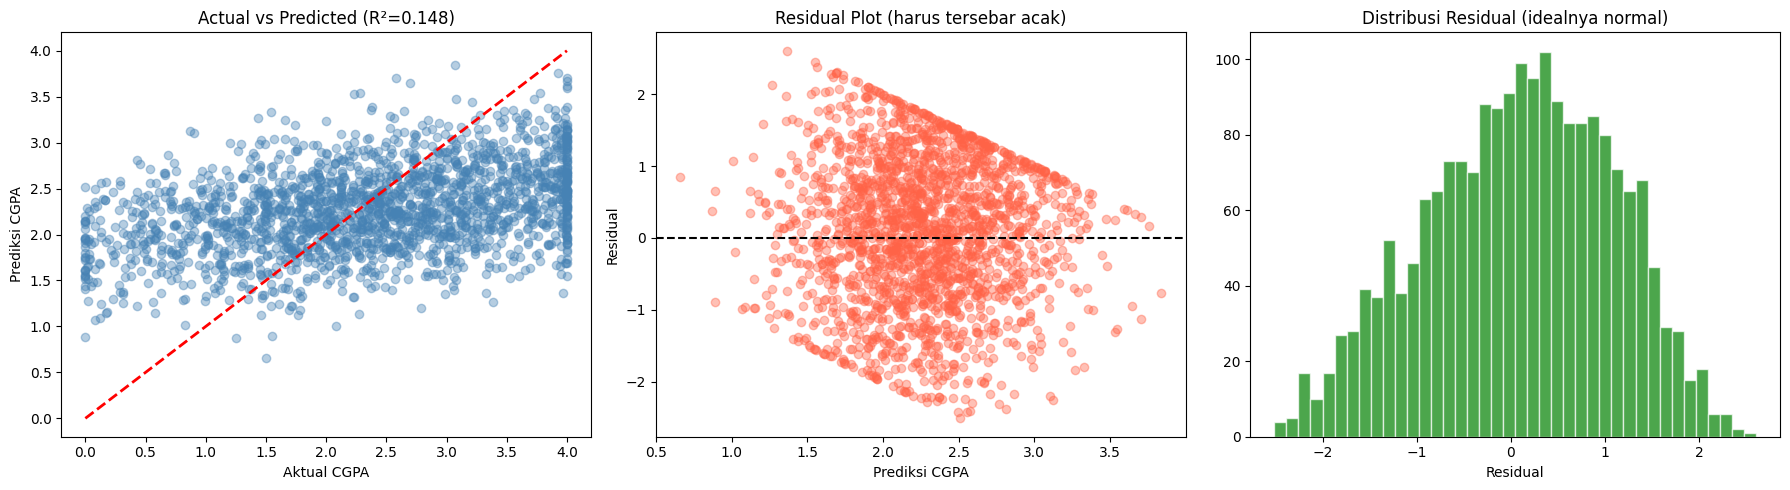

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'r--', lw=2)
axes[0].set_xlabel('Aktual CGPA')
axes[0].set_ylabel('Prediksi CGPA')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')

# Residual plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.4, color='tomato')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Prediksi CGPA')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot (harus tersebar acak)')

# Distribusi residual
axes[2].hist(residuals, bins=40, color='green', alpha=0.7, edgecolor='white')
axes[2].set_xlabel('Residual')
axes[2].set_title('Distribusi Residual (idealnya normal)')

plt.tight_layout()
plt.show()

In [9]:
# Koefisien linear regression
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', key=abs, ascending=False)

print('TOP 10 KOEFISIEN (pengaruh terbesar terhadap CGPA):')
print(coef_df.head(10).to_string(index=False))
print(f'\nIntercept: {model.intercept_:.4f}')

TOP 10 KOEFISIEN (pengaruh terbesar terhadap CGPA):
                Fitur  Koefisien
         Stress_Index  -0.395508
  Study_Hours_per_Day   0.231711
      Attendance_Rate   0.214558
                  Age  -0.020245
Assignment_Delay_Days  -0.015671
          Scholarship   0.007596
               Gender  -0.007559
        Part_Time_Job  -0.007048
             Semester   0.005229
           Department  -0.004974

Intercept: 2.2862


---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Panduan R² (R-squared):
| R² | Interpretasi |
|----|-------------|
| < 0.3 | Buruk — Model hampir tidak menjelaskan varians |
| 0.3–0.5 | Lemah |
| 0.5–0.7 | Cukup |
| 0.7–0.85 | Baik |
| > 0.85 | Sangat Baik |
| ≈ 1.0 | Sempurna — Waspadai overfitting atau data leakage! |

### Panduan MAE (untuk CGPA range 0–4):
| MAE | Interpretasi |
|-----|-------------|
| < 0.1 | Prediksi sangat akurat |
| 0.1–0.2 | Baik |
| 0.2–0.4 | Cukup |
| > 0.4 | Perlu perbaikan |

### Cek Residual (cara mengetahui asumsi linear terpenuhi):
- Residual **tersebar acak** di sekitar 0 → Asumsi terpenuhi 
- Residual membentuk pola → Linear regression tidak optimal
- Residual **distribusi normal** → Asumsi terpenuhi 

### Deteksi Overfitting:
```python
# Jika Train R² >> Test R² → Overfitting
# Linear Regression jarang overfitting, tapi Ridge/Lasso bisa bantu jika underfitting
```

In [10]:
r2_train = r2_score(y_train, model.predict(X_train_s))
r2_test = r2_score(y_test, model.predict(X_test_s))
print(f'Train R² : {r2_train:.4f}')
print(f'Test  R² : {r2_test:.4f}')

if r2_train - r2_test > 0.1:
    print('  Kemungkinan OVERFITTING — coba Ridge/Lasso')
elif r2_test < 0.5:
    print('  R² rendah — coba model non-linear atau tambah fitur')
else:
    print('  Model terlihat baik!')

# Cross-validation R² (impute NaN dulu, X masih mengandung missing values)
from sklearn.pipeline import Pipeline
cv_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
X_cv = cv_pipe.fit_transform(X)

cv_r2 = cross_val_score(model, X_cv, y, cv=5, scoring='r2')
print(f'\nCross-Val R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

Train R² : 0.2255
Test  R² : 0.1485
  R² rendah — coba model non-linear atau tambah fitur

Cross-Val R² (5-fold): 0.2089 ± 0.0166


---
## 7.  Cara Mengoptimasi Model

### Langkah 1: Jika R² rendah / RMSE tinggi:
- Tambahkan fitur baru (feature engineering)
- Coba transformasi fitur (log, sqrt)
- Pertimbangkan model non-linear (RF, XGBoost)

### Langkah 2: Jika Ada Multicollinearity:
- Gunakan Ridge (alpha=0.1–100)
- Cek VIF (Variance Inflation Factor)

### Langkah 3: Feature Selection:
- Gunakan Lasso — fitur tidak berguna akan zero-out otomatis

### Bonus: Polynomial Features untuk menangkap non-linearitas:

In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV

# Pipeline: Polynomial + Ridge
poly_ridge = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=1.0))
])

poly_ridge.fit(X_train_s, y_train)
y_poly = poly_ridge.predict(X_test_s)

print('Polynomial Regression (degree=2) + Ridge:')
print(f'  MAE  : {mean_absolute_error(y_test, y_poly):.4f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_poly)):.4f}')
print(f'  R²   : {r2_score(y_test, y_poly):.4f}')

# Tuning optimal alpha untuk Ridge
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], cv=5)
ridge_cv.fit(X_train_s, y_train)
print(f'\nRidgeCV optimal alpha: {ridge_cv.alpha_}')
y_rc = ridge_cv.predict(X_test_s)
print(f'Ridge optimal → R²: {r2_score(y_test, y_rc):.4f}')

Polynomial Regression (degree=2) + Ridge:
  MAE  : 0.8291
  RMSE : 1.0058
  R²   : 0.1358

RidgeCV optimal alpha: 100.0
Ridge optimal → R²: 0.1488


---
## 8.  Cara Menyimpan Model

In [12]:
os.makedirs('saved_models', exist_ok=True)

joblib.dump(model, 'saved_models/linear_regression_cgpa.pkl')
joblib.dump(scaler, 'saved_models/scaler_linreg.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_columns_linreg.pkl')

print(' Linear Regression model tersimpan!')

 Linear Regression model tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [13]:
loaded_model = joblib.load('saved_models/linear_regression_cgpa.pkl')
loaded_scaler = joblib.load('saved_models/scaler_linreg.pkl')
loaded_cols = joblib.load('saved_models/feature_columns_linreg.pkl')

print('Model dimuat ')
print(f'Fitur yang dibutuhkan: {loaded_cols}')

Model dimuat 
Fitur yang dibutuhkan: ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'Stress_Index', 'Semester', 'Department', 'Parental_Education']


In [14]:
# Prediksi CGPA mahasiswa baru
new_student = pd.DataFrame([{
    'Age': 20,
    'Gender': 1,
    'Family_Income': 35000,
    'Internet_Access': 1,
    'Study_Hours_per_Day': 5.0,
    'Attendance_Rate': 88,
    'Assignment_Delay_Days': 1,
    'Travel_Time_Minutes': 20,
    'Part_Time_Job': 0,
    'Scholarship': 1,
    'Stress_Index': 4,
    'Semester': 3,
    'Department': 1,
    'Parental_Education': 3
}])[loaded_cols]

new_scaled = loaded_scaler.transform(new_student)
predicted_cgpa = loaded_model.predict(new_scaled)[0]

print(f'\nPrediksi CGPA: {predicted_cgpa:.2f}')

if predicted_cgpa >= 3.5:
    grade = ' Cumlaude'
elif predicted_cgpa >= 3.0:
    grade = '⭐ Sangat Memuaskan'
elif predicted_cgpa >= 2.5:
    grade = ' Memuaskan'
else:
    grade = ' Perlu Perbaikan'

print(f'Kategori: {grade}')


Prediksi CGPA: 3.00
Kategori: ⭐ Sangat Memuaskan
